### This example demonstrates how to use the `fcon.py` functions to generate the JSD and other properties of frequency conversion in nonlinear waveguides using the *[Generator of Momentum](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.105.013708)* method. These functions are valid for *arbitrary dispersion* for all modes. Works for arbitrary poling (see `comparing_fcon_lin_arb.ipynb` notebook).

This method is useful when considering dispersion engineered waveguides where the phase-mismatch, $\Delta k(\omega,\omega')$, does not contain linear frequency-dependent terms (i.e. group-velocity matching). When this is the case, one needs to keep quadratic (and possibly higher order) frequency-dependent terms, at which point the linear method fails. Unlike the linear method, the equations of motion are $z$-dependent and as such the functions take longer to evaluate (few-several minutes).

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from NeedALight.fcon import FPulsed_arb

This section introduces all relevant quantities needed to use the functions and generate the wanted properties.

In [23]:
#Parameters for calculations
N = 301  # Number of frequency values
l = 1.0  # amplification region length
sig = 1  # pump wave packet spread

#Dispersions
v = 0.1  # velocity of all modes
bs = 3     #signal group-velocity dispersion
bi = 1    #idler group-velocity dispersion  
bp = -3e-1     #pump group-velocity dispersion
#Frequency values
wi = -10
wf = 10
w = np.linspace(wi, wf, N)
dw = np.abs(w[1]-w[0])
#Dispersion relations
ks = w/v+bs*w**2
ki = w/v+bi*w**2
kp_w = (w-w[:,np.newaxis])/v+bp*(w-w[:,np.newaxis])**2

#Interaction strength
Np = 0.0172 # Number of pump photons: Vary this to modify gain values
gamma = 1/np.sqrt(2 * np.pi * v**3)


#Spatial grid and domain
Ndomain = 1000  # Number of spatial points for non-linear/crystal grid
dz = l / Ndomain
z_list = np.linspace(-l/2,l/2-dz, Ndomain)
domain = np.asarray([1]*len(z_list))


#Defining gaussian pump pulse
def pump(x, Np, scale=1):
    return np.sqrt(Np)*np.exp(-((x) ** 2) / (2 * (sig*scale) ** 2)) / np.power(np.pi * (sig*scale)**2, 1 / 4)

pump_w = lambda x: pump(x, Np)

Before we use our built-in function to generate the wanted properties, we first consider the low-gain approximation for the JSD(the product of the pump envelope and phase-matching functions). For illustrative purposes, we include plots of the pump envelope and phase-matching function as well.

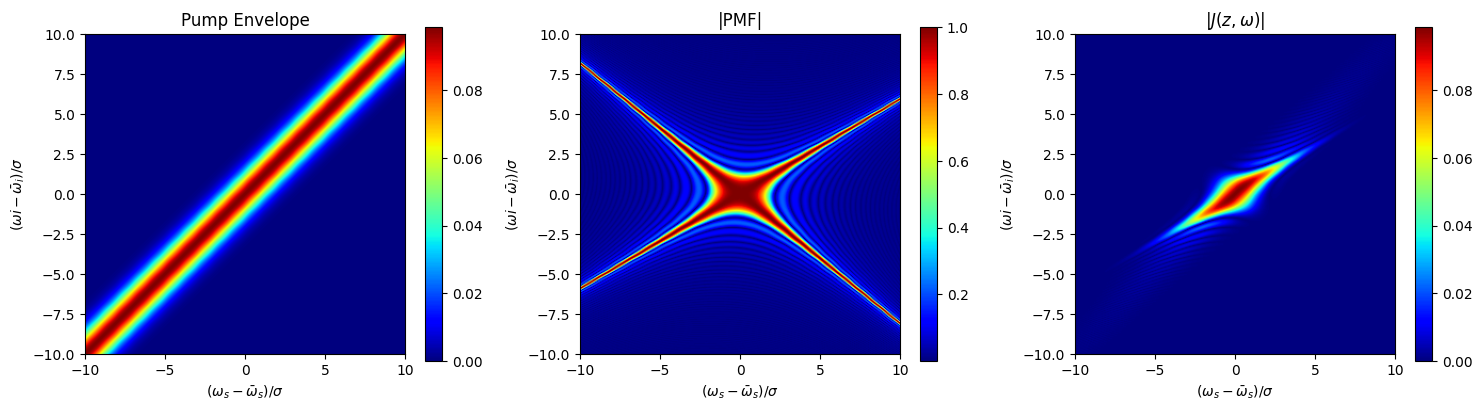

In [24]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
im = axs[0].imshow(pump_w(w-w[:,np.newaxis]), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
axs[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[0].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
axs[0].set_title('Pump Envelope')
plt.colorbar(im, orientation="vertical")

im1 = axs[1].imshow(np.abs(np.sinc((kp_w+ks[:,np.newaxis]-ki)*l/(2*np.pi))), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
axs[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[1].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
axs[1].set_title('|PMF|')
plt.colorbar(im1, orientation="vertical")

im2 = axs[2].imshow(np.abs(pump_w(w-w[:,np.newaxis])*np.sinc((kp_w+ks[:,np.newaxis]-ki)*l/(2*np.pi))), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
axs[2].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
axs[2].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
axs[2].set_title(r"$|J(z, \omega)|$")
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()

We can also obtain an approximate value for the low-gain Selectivity as well as the temporal modes (Note that these agree with the Selectivity and first temporal mode structure when using the built in function in the low-gain regime):

In [25]:
L2, D, Vh = np.linalg.svd(0.000000001*pump_w(w-w[:,np.newaxis])*np.sinc((kp_w+ks[:,np.newaxis]-ki)*l/(2*np.pi)))  #SVD of low-gain JSD
u_low = L2[:,0] #Isolating first signal schmidt mode
#Obtaining low-gain Schmidt number
D = np.diag(D)
K_low =  np.trace(np.sin(D) ** 4) / (np.trace(np.sin(D) ** 2)) ** 2
print('Approximate Selecivity in the low-gain is %f' %K_low)

Approximate Selecivity in the low-gain is 0.482828


Next we consider the JSD etc for a higher value of gain (determined by Np above).

In [26]:
T_arb, J_arb, Eff_arb, S_arb, Us_arb, Ui_arb, Vs_arb, Vi_arb = FPulsed_arb(ks, ki, kp_w, gamma, w, z_list, domain, pump_w)

Note that when using the `Fpulsed_arb` function, we need to plot the *Transpose* of the generated JSD. This is because in the linear case, the built-in `JSD` function takes the transpose to output the JSD as a function of $(\omega_{S}, \omega_{I})$. However, the `Fpulsed_arb` already properly outputs matrices as a function of $(\omega_{S}, \omega_{I})$ and so we need to undo the transpose.  

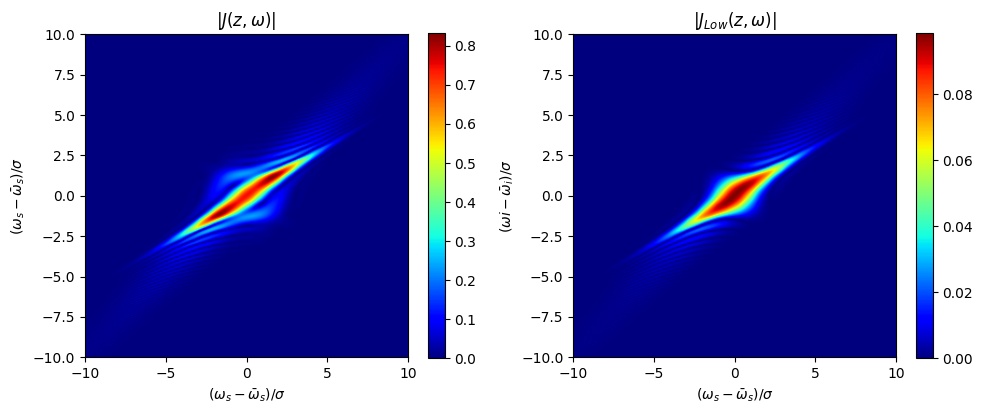

The Selectivity is S = 0.216128
The conversion efficiency is η = 0.799


In [27]:
# Generating plot for the abs(JSA)
fig, ax = plt.subplots(1, 2, figsize=(10,4))
im = ax[0].imshow(np.abs(J_arb).T,cmap="jet",origin="lower",extent=[w[0] ,w[-1],w[0] ,w[-1]])
ax[0].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[0].set_ylabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[0].set_title(r"$|J(z, \omega)|$")
plt.colorbar(im, orientation="vertical")

im2 = ax[1].imshow(np.abs(pump_w(w-w[:,np.newaxis])*np.sinc((kp_w+ks[:,np.newaxis]-ki)*l/(2*np.pi))), cmap="jet", origin="lower", extent=[w[0],w[-1],w[0],w[-1]])
ax[1].set_xlabel(r"$(\omega_{s}-\bar{\omega}_{s})/\sigma$")
ax[1].set_ylabel(r"$(\omega{i}-\bar{\omega}_{i})/\sigma$")
ax[1].set_title(r"$|J_{Low}(z, \omega)|$")
plt.colorbar(im2, orientation="vertical")

fig.tight_layout()
plt.show()

print('The Selectivity is S = %f' %S_arb)
print("The conversion efficiency is \u03B7 = %1.3f" %Eff_arb[-1])

For the chosen dispersion, the high-gain effects on the JSD are visible. The Selectivity is also reduced greatly. We can also consider how the output signal modes behave. Here we consider the first signal output mode. We choose a gauge where the imaginary part of the mode is zero at the central frequency.

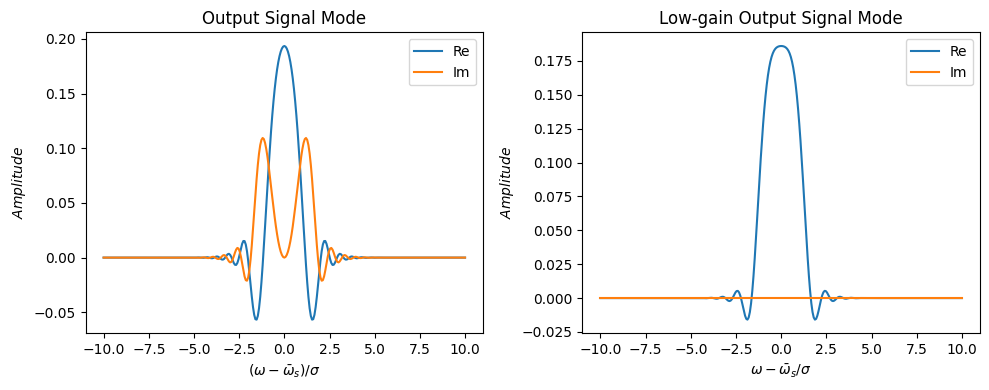

In [29]:
#Looking at the temporal modes via Nums matrix
mark=1 #this just takes the first eigenmode of interest. Choose a different value to look at different ones.


fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].plot(w, np.real(np.exp(-1j*np.angle(Us_arb[(N-1)//2,-mark]))*Us_arb[:,-mark]), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax[0].plot(w, np.imag(np.exp(-1j*np.angle(Us_arb[(N-1)//2,-mark]))*Us_arb[:,-mark]), label='Im')
ax[0].set_xlabel(r"$(\omega-\bar{\omega}_{s})/\sigma$")
ax[0].set_ylabel(r"$Amplitude$")
ax[0].set_title('Output Signal Mode')
ax[0].legend()

ax[1].plot(w, np.real(np.exp(-1j*np.angle(u_low[(N-1)//2]))*u_low), label='Re') #Here we multiply by a phase factor such that the imaginary part is 0 at the origin.
ax[1].plot(w, np.imag(np.exp(-1j*np.angle(u_low[(N-1)//2]))*u_low), label='Im')
ax[1].set_xlabel(r"$\omega-\bar{\omega}_{s}/\sigma$")
ax[1].set_ylabel(r"$Amplitude$")
ax[1].set_title("Low-gain Output Signal Mode")
ax[1].legend()

fig.tight_layout()
plt.show()

We see that high-gain effects induce an imaginary part to the Signal ouptut modes.